# Phân tích doanh thu thương mại điện tử: Yếu tố liên quan, rủi ro và cơ hội

## 1. Câu hỏi và hướng phân tích

**Mức doanh thu thấp hơn từ năm 2019 gắn với những thay đổi nào, và doanh nghiệp nên chú ý đến tín hiệu nào từ khách hàng?**

Báo cáo sử dụng dữ liệu mô phỏng của một doanh nghiệp thời trang thương mại điện tử Việt Nam. Phân tích bắt đầu từ doanh thu (Revenue), tách thành số đơn hàng (Orders) và giá trị trung bình mỗi đơn (AOV), sau đó xem xét khách hàng hoạt động, tần suất đặt đơn, khách mới, khách quay lại và hành vi đặt lại trong cùng khoảng theo dõi.

Các so sánh doanh thu và hoạt động khách hàng dùng **tháng 1/2013 đến tháng 12/2018 (72 tháng)** và **tháng 1/2019 đến tháng 12/2022 (48 tháng)**. Cách chia này mô tả sự thay đổi quan sát được, không dùng để ước lượng tác động nhân quả. Dữ liệu năm 2012 chưa đủ năm chỉ xuất hiện trong biểu đồ doanh thu và được dùng làm lịch sử để phân loại khách hàng. Không sử dụng quan sát sau **ngày 31/12/2022**.

## 2. Tổng quan dữ liệu

**Câu hỏi:** Dữ liệu và thời gian quan sát có đủ để so sánh doanh thu và khách hàng một cách nhất quán không?

Phân tích sử dụng bốn bảng. Lịch sử đơn hàng bắt đầu từ ngày 4/7/2012; không có lịch sử khách hàng trước đó. Vì vậy, đơn đầu tiên quan sát được chỉ đánh dấu lần đầu khách xuất hiện trong dữ liệu, chưa chắc là lần mua đầu tiên của họ.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import HTML, display

DATA_DIR = Path("data")
MILLION = 1_000_000
PRE_START = pd.Timestamp("2013-01-01")
POST_START = pd.Timestamp("2019-01-01")
CUTOFF = pd.Timestamp("2022-12-31")
PERIOD_COLUMNS = ["2013-2018", "2019-2022"]
MONTH_NAMES = ["T1", "T2", "T3", "T4", "T5", "T6",
               "T7", "T8", "T9", "T10", "T11", "T12"]

pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def show_table(df, formatters=None):
    column_formatters = {
        column: spec.format if isinstance(spec, str) else spec
        for column, spec in (formatters or {}).items()
    }
    text_labels = {
        "One day": "Một ngày",
        "One order": "Một đơn hàng",
        "One order-product line": "Một dòng sản phẩm trong đơn",
        "One customer": "Một khách hàng",
        "Dated through orders": "Lấy ngày từ orders",
        "Signup date audited below": "Ngày đăng ký được kiểm tra ở phần sau",
        "2012-07-04 to 2022-12-31": "2012-07-04 đến 2022-12-31",
        "Reconstructed order-item value": "Giá trị hàng tính lại từ chi tiết đơn",
        "Official sales Revenue": "Doanh thu trong sales",
        "Revenue per month, million VND": "Doanh thu bình quân tháng, triệu VND",
        "Orders per month": "Số đơn bình quân tháng",
        "AOV, VND per order": "AOV, VND/đơn",
        "Active customers per month": "Khách hoạt động bình quân tháng",
        "Orders per active customer": "Số đơn trên mỗi khách hoạt động",
        "New purchasing customers": "Khách mới",
        "Returning active customers": "Khách quay lại có hoạt động",
        "Observed Revenue": "Doanh thu đã quan sát",
        "Forecast dates; Revenue unknown": "Ngày cần dự báo; chưa biết doanh thu",
        "Development 1": "Lượt phát triển 1",
        "Development 2": "Lượt phát triển 2",
        "Development 3": "Lượt phát triển 3",
        "Final backtest": "Kiểm định cuối",
    }
    for column in df.select_dtypes(include=["object", "string"]).columns:
        if column not in column_formatters:
            column_formatters[column] = lambda value: text_labels.get(value, value)
    display(HTML(df.to_html(index=False, formatters=column_formatters, na_rep="", border=0)))


def format_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("Năm")
    ax.grid(True, alpha=0.25)

In [2]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(
    DATA_DIR / "order_items.csv",
    usecols=["order_id", "quantity", "unit_price"],
)
customers = pd.read_csv(
    DATA_DIR / "customers.csv", usecols=["customer_id", "signup_date"],
    parse_dates=["signup_date"],
)

assert sales["Date"].is_unique
assert sales["Date"].max() == CUTOFF
assert sales["Date"].tolist() == list(pd.date_range(sales["Date"].min(), CUTOFF))
assert orders["order_id"].is_unique
assert customers["customer_id"].is_unique
assert orders["order_date"].between(sales["Date"].min(), CUTOFF).all()
assert orders["order_date"].max() == CUTOFF
assert orders["customer_id"].isin(customers["customer_id"]).all()
assert not sales[["Date", "Revenue"]].isna().any().any()
assert not orders[["order_id", "order_date", "customer_id"]].isna().any().any()
assert not order_items.isna().any().any()

overview = pd.DataFrame([
    ["sales", len(sales), "One day", "2012-07-04 to 2022-12-31"],
    ["orders", len(orders), "One order", "2012-07-04 to 2022-12-31"],
    ["order_items", len(order_items), "One order-product line", "Dated through orders"],
    ["customers", len(customers), "One customer", "Signup date audited below"],
], columns=["Table", "Rows", "Grain", "Date coverage"])
show_table(overview, {"Rows": "{:,.0f}"})

Table,Rows,Grain,Date coverage
sales,"3,833",Một ngày,2012-07-04 đến 2022-12-31
orders,"646,945",Một đơn hàng,2012-07-04 đến 2022-12-31
order_items,"714,669",Một dòng sản phẩm trong đơn,Lấy ngày từ orders
customers,"121,930",Một khách hàng,Ngày đăng ký được kiểm tra ở phần sau


## 3. Định nghĩa chỉ số và chuẩn bị dữ liệu

**Câu hỏi:** Có thể tính lại doanh thu từ giao dịch mà không đếm trùng đơn hàng không?

- **Revenue:** doanh thu ngày trong `sales.Revenue`; giá trị mỗi đơn được tính bằng tổng `quantity × unit_price` của các dòng thuộc đơn đó.
- **Orders:** số mã đơn hàng riêng biệt, giữ mọi trạng thái để khớp với doanh thu của bộ dữ liệu.
- **AOV:** Revenue chia cho Orders, đơn vị VND/đơn.
- **Khách hàng hoạt động trong tháng:** số `customer_id` riêng biệt có ít nhất một đơn được ghi nhận trong tháng.
- **Tần suất đặt đơn trong tháng:** Orders chia cho số khách hàng hoạt động.

Không trừ chiết khấu lần nữa vì `unit_price` đã phản ánh mức giá dùng để tính doanh thu. Các chỉ số khách hàng cũng giữ mọi trạng thái đơn, nên phản ánh hoạt động đặt đơn được ghi nhận, không chỉ các giao dịch đã hoàn tất.

In [3]:
# Aggregate line items before the one-to-one order merge.
order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"]
order_level = order_items.groupby("order_id", as_index=False).agg(
    order_value=("line_revenue", "sum"),
)
assert set(order_level["order_id"]) == set(orders["order_id"])
orders_enriched = orders.merge(
    order_level, on="order_id", how="left", validate="one_to_one",
)
assert len(orders_enriched) == len(orders)
assert orders_enriched["order_value"].notna().all()
np.testing.assert_allclose(
    orders_enriched["order_value"].sum(), sales["Revenue"].sum(),
    rtol=0, atol=0.01,
)

reconciliation = pd.DataFrame({
    "Source": ["Reconstructed order-item value", "Official sales Revenue"],
    "Total, VND": [orders_enriched["order_value"].sum(), sales["Revenue"].sum()],
})
show_table(reconciliation, {"Total, VND": "{:,.2f}"})

Source,"Total, VND"
Giá trị hàng tính lại từ chi tiết đơn,"16,430,476,585.53"
Doanh thu trong sales,"16,430,476,585.53"


In [4]:
status_summary = orders_enriched.groupby("order_status", as_index=False).agg(
    Orders=("order_id", "nunique"),
    item_value=("order_value", "sum"),
).sort_values("Orders", ascending=False)
status_summary["Order-item value, million VND"] = status_summary.pop("item_value") / MILLION
show_table(
    status_summary.rename(columns={"order_status": "Status"}),
    {"Orders": "{:,.0f}", "Order-item value, million VND": "{:,.1f}"},
)

Status,Orders,"Order-item value, million VND"
delivered,"516,716","13,117.1"
cancelled,"59,462","1,515.9"
returned,"36,142",907.5
shipped,"13,773",353.4
paid,"13,577",345.9
created,"7,275",190.7


**Kết quả:** Hai nguồn cùng đạt **16,430,476,585.53 VND**, với sai số đối chiếu trong ngưỡng 0.01 VND. Giá trị hàng trong các đơn bị hủy là **1,515.9 triệu VND**; trong các đơn bị trả lại là **907.5 triệu VND**.

**Nhận xét:** Tổng giá trị hàng ở mọi trạng thái khớp với doanh thu của bộ dữ liệu mô phỏng. Loại các trạng thái này sẽ làm thay đổi chỉ số. Không nên hiểu đây là doanh thu được ghi nhận theo chuẩn kế toán hoặc doanh thu từ các đơn đã hoàn tất. Doanh thu theo tháng cũng được đối chiếu trước khi phân rã.

## 4. Doanh thu theo thời gian

**Câu hỏi:** Doanh thu giảm chỉ trong thời gian ngắn hay duy trì ở mức thấp hơn?

Biểu đồ theo tháng giúp tách thay đổi về mặt bằng doanh thu khỏi biến động hằng ngày. Giai đoạn tháng 7 đến tháng 12/2012 chỉ được đưa vào để tham khảo; riêng tháng 7 cũng chưa có đủ ngày.

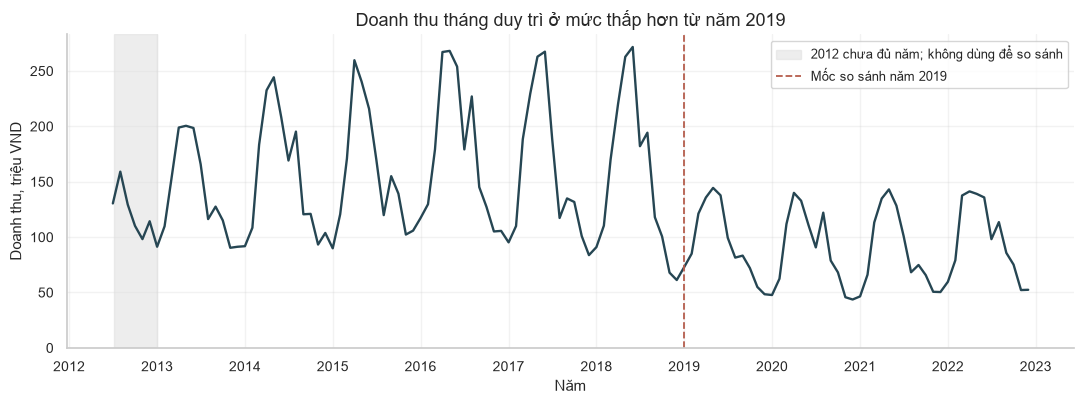

In [5]:
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.to_period("M").dt.to_timestamp()
sales["month_num"] = sales["Date"].dt.month
monthly_sales = sales.groupby("month", as_index=False).agg(
    revenue=("Revenue", "sum"),
)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(monthly_sales["month"], monthly_sales["revenue"] / MILLION,
        color="#264653", linewidth=1.7)
ax.axvspan(sales["Date"].min(), PRE_START, color="#dddddd", alpha=0.5,
           label="2012 chưa đủ năm; không dùng để so sánh")
ax.axvline(POST_START, color="#B55D4C", linestyle="--", linewidth=1.3,
           label="Mốc so sánh năm 2019")
ax.set_title("Doanh thu tháng duy trì ở mức thấp hơn từ năm 2019")
ax.set_ylabel("Doanh thu, triệu VND")
ax.set_ylim(bottom=0)
format_time_axis(ax)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

**Kết quả:** Doanh thu duy trì ở mức thấp hơn trong suốt giai đoạn 2019-2022, nhưng vẫn có các đợt cao điểm hằng năm. Phần so sánh bên dưới cho thấy doanh thu bình quân tháng giảm **41.5%**.

**Nhận xét:** Sự giảm kéo dài là vấn đề chính cần tìm hiểu. Các đợt cao điểm lặp lại cũng cho thấy cần xét yếu tố mùa vụ.

**Câu hỏi tiếp theo:** Sau khi loại ảnh hưởng của mức doanh thu từng năm, mùa vụ có còn rõ không?

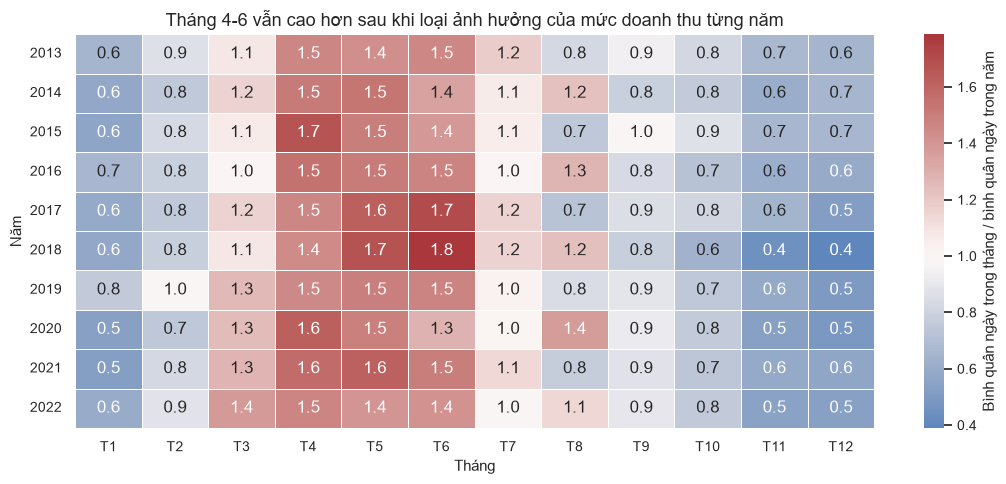

In [6]:
complete_year_sales = sales[sales["year"].between(2013, 2022)]
monthly_avg_daily = complete_year_sales.groupby(["year", "month_num"], as_index=False).agg(
    avg_daily_revenue=("Revenue", "mean"),
)
year_avg_daily = complete_year_sales.groupby("year")["Revenue"].mean().rename("annual_avg")
relative_monthly = monthly_avg_daily.join(year_avg_daily, on="year", validate="many_to_one")
relative_monthly["relative_to_year_avg"] = relative_monthly["avg_daily_revenue"] / relative_monthly["annual_avg"]
relative_heatmap = relative_monthly.pivot(
    index="year", columns="month_num", values="relative_to_year_avg",
)
seasonal_index = relative_monthly.groupby("month_num")["relative_to_year_avg"].mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(relative_heatmap, cmap="vlag", center=1, annot=True, fmt=".1f",
            linewidths=0.4, xticklabels=MONTH_NAMES, ax=ax,
            cbar_kws={"label": "Bình quân ngày trong tháng / bình quân ngày trong năm"})
ax.set_title("Tháng 4-6 vẫn cao hơn sau khi loại ảnh hưởng của mức doanh thu từng năm")
ax.set_xlabel("Tháng")
ax.set_ylabel("Năm")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

**Kết quả:** Trong mười năm đầy đủ, doanh thu bình quân ngày của tháng 4, 5 và 6 lần lượt bằng **1.52, 1.53 và 1.48 lần** bình quân ngày của năm tương ứng. Tháng 10, 11 và 12 lần lượt bằng **0.76, 0.59 và 0.55 lần**. Tháng 8 vẫn có dạng mạnh, yếu xen kẽ giữa các năm, nhưng đây chưa phải vấn đề chính so với mức giảm kéo dài.

**Nhận xét:** Mùa vụ vẫn xuất hiện trong giai đoạn doanh thu thấp hơn. Vì vậy, so sánh chính dùng các năm đủ tháng, để mọi tháng đều có trọng số như nhau, thay vì đối chiếu mùa cao điểm với mùa thấp điểm. Mẫu hình quá khứ không bảo đảm nhu cầu tương lai sẽ lặp lại.

**Câu hỏi tiếp theo:** Mức doanh thu thấp hơn gắn với ít đơn hàng hơn, AOV thấp hơn, hay cả hai?

## 5. Phân rã doanh thu

**Câu hỏi:** Thành phần nào trong **Revenue = Orders × AOV** gắn với chênh lệch giữa hai giai đoạn?

Doanh thu và số đơn được so sánh theo bình quân tháng, trên **72 tháng của 2013-2018** và **48 tháng của 2019-2022**. **AOV của cả giai đoạn bằng tổng Revenue chia cho tổng Orders**, không phải trung bình đơn giản của AOV từng tháng. Cách tính này giữ đúng đẳng thức giữa doanh thu bình quân tháng, số đơn bình quân tháng và AOV của giai đoạn.

Mọi tỷ lệ thay đổi bên dưới được tính bằng **(giá trị giai đoạn sau / giá trị giai đoạn trước - 1) × 100**. Năm 2012 chưa đầy đủ nên được loại khỏi so sánh.

In [7]:
orders_enriched["month"] = orders_enriched["order_date"].dt.to_period("M").dt.to_timestamp()
orders_enriched["year"] = orders_enriched["order_date"].dt.year
monthly_metrics = orders_enriched.groupby("month", as_index=False).agg(
    revenue=("order_value", "sum"),
    orders=("order_id", "nunique"),
    active_customers=("customer_id", "nunique"),
)
monthly_metrics["year"] = monthly_metrics["month"].dt.year
monthly_metrics["aov"] = monthly_metrics["revenue"] / monthly_metrics["orders"]
monthly_metrics["orders_per_active_customer"] = monthly_metrics["orders"] / monthly_metrics["active_customers"]

monthly_check = monthly_metrics.merge(
    monthly_sales.rename(columns={"revenue": "official_revenue"}),
    on="month", how="outer", validate="one_to_one", indicator=True,
)
assert monthly_check["_merge"].eq("both").all()
np.testing.assert_allclose(monthly_check["revenue"], monthly_check["official_revenue"],
                           rtol=0, atol=0.01)

In [8]:
def summarize_period(df):
    return pd.Series({
        "Revenue per month": df["revenue"].mean(),
        "Orders per month": df["orders"].mean(),
        "AOV": df["revenue"].sum() / df["orders"].sum(),
        "Active customers per month": df["active_customers"].mean(),
        "Orders per active customer": df["orders"].sum() / df["active_customers"].sum(),
    })


pre_period = monthly_metrics[monthly_metrics["year"].between(2013, 2018)]
post_period = monthly_metrics[monthly_metrics["year"].between(2019, 2022)]
assert pre_period["month"].tolist() == list(pd.date_range("2013-01-01", "2018-12-01", freq="MS"))
assert post_period["month"].tolist() == list(pd.date_range("2019-01-01", "2022-12-01", freq="MS"))
period_summary = pd.DataFrame({
    "2013-2018": summarize_period(pre_period),
    "2019-2022": summarize_period(post_period),
})
period_summary["Percent change"] = period_summary["2019-2022"] / period_summary["2013-2018"] - 1
period_ratios = period_summary["2019-2022"] / period_summary["2013-2018"]
np.testing.assert_allclose(
    period_ratios["Revenue per month"],
    period_ratios["Orders per month"] * period_ratios["AOV"],
)
period_display = period_summary.loc[["Revenue per month", "Orders per month", "AOV"]].copy()
period_display.loc["Revenue per month", PERIOD_COLUMNS] /= MILLION
period_display = period_display.rename(index={
    "Revenue per month": "Revenue per month, million VND",
    "AOV": "AOV, VND per order",
})
show_table(period_display.reset_index(names="Metric"), {
    "2013-2018": "{:,.2f}", "2019-2022": "{:,.2f}", "Percent change": "{:+.1%}",
})

Metric,2013-2018,2019-2022,Percent change
"Doanh thu bình quân tháng, triệu VND",156.73,91.75,-41.5%
Số đơn bình quân tháng,"6,498.38","3,062.73",-52.9%
"AOV, VND/đơn","24,119.01","29,957.64",+24.2%


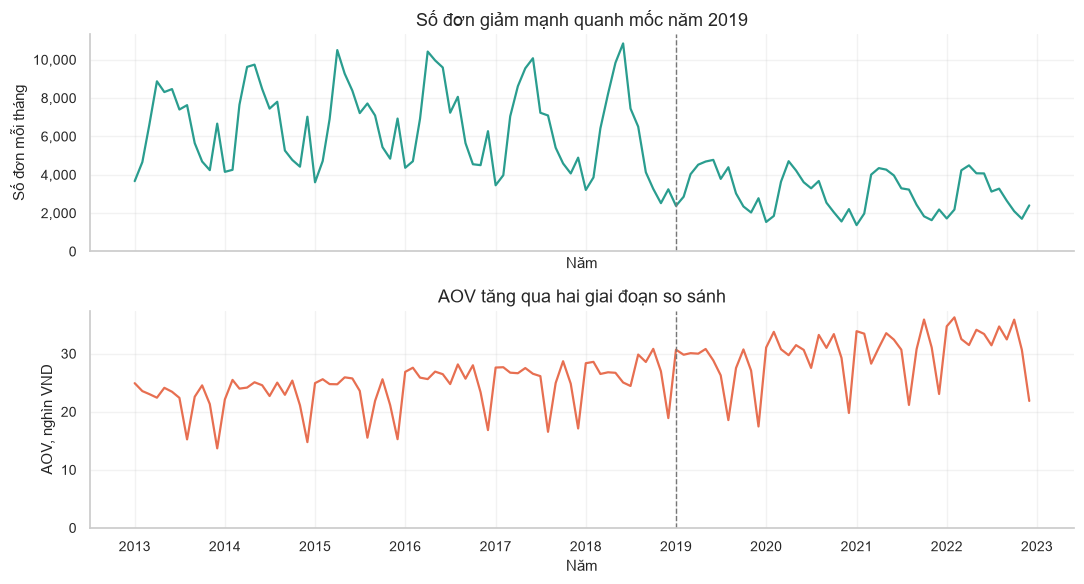

In [9]:
comparison_months = monthly_metrics[monthly_metrics["year"].between(2013, 2022)].copy()
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(comparison_months["month"], comparison_months["orders"],
             color="#2A9D8F", linewidth=1.6)
axes[0].set_title("Số đơn giảm mạnh quanh mốc năm 2019")
axes[0].set_ylabel("Số đơn mỗi tháng")
axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].plot(comparison_months["month"], comparison_months["aov"] / 1000,
             color="#E76F51", linewidth=1.6)
axes[1].set_title("AOV tăng qua hai giai đoạn so sánh")
axes[1].set_ylabel("AOV, nghìn VND")
axes[1].set_ylim(bottom=0)
for ax in axes:
    ax.axvline(POST_START, color="#777777", linestyle="--", linewidth=1)
    format_time_axis(ax)
plt.tight_layout()
plt.show()

**Kết quả:** Doanh thu bình quân tháng giảm từ **156.73 triệu xuống 91.75 triệu VND (41.5%)**. Số đơn giảm từ **6,498 xuống 3,063 đơn/tháng (52.9%)**, trong khi AOV có trọng số tăng từ **24,119 lên 29,958 VND (24.2%)**.

**Nhận xét:** Trong đẳng thức doanh thu, số đơn là thành phần giảm: tỷ số Orders **0.471** nhân với tỷ số AOV **1.242** bằng tỷ số Revenue **0.585**. AOV cao hơn bù lại một phần mức giảm của số đơn về mặt số học. Đây không phải ước lượng doanh thu nếu doanh nghiệp thực hiện một chính sách giá khác.

**Câu hỏi tiếp theo:** Những tháng có nhiều đơn có đồng thời có AOV thấp hơn không?

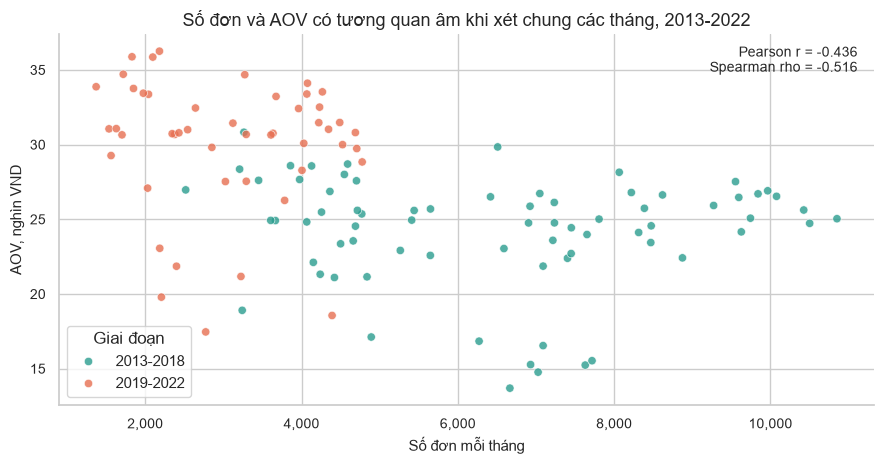

In [10]:
plot_data = comparison_months.copy()
plot_data["Period"] = np.where(plot_data["year"] < 2019, "2013-2018", "2019-2022")
plot_data["AOV, thousand VND"] = plot_data["aov"] / 1000
orders_aov_pearson = plot_data[["orders", "aov"]].corr(method="pearson").iloc[0, 1]
orders_aov_spearman = plot_data[["orders", "aov"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.scatterplot(data=plot_data, x="orders", y="AOV, thousand VND", hue="Period",
                hue_order=PERIOD_COLUMNS, palette=["#2A9D8F", "#E76F51"],
                alpha=0.8, ax=ax)
ax.set_title("Số đơn và AOV có tương quan âm khi xét chung các tháng, 2013-2022")
ax.set_xlabel("Số đơn mỗi tháng")
ax.set_ylabel("AOV, nghìn VND")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.text(0.98, 0.97,
        f"Pearson r = {orders_aov_pearson:.3f}\nSpearman rho = {orders_aov_spearman:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10)
ax.legend(loc="lower left", title="Giai đoạn")
plt.tight_layout()
plt.show()

**Kết quả:** Trong 120 tháng của giai đoạn 2013-2022, Orders và AOV có tương quan âm khi xét chung: **Pearson r = -0.436; Spearman rho = -0.516**. Các tháng ít đơn, AOV cao hơn cũng tập trung ở giai đoạn sau.

**Nhận xét:** Mùa vụ, xu hướng thời gian và sự thay đổi giữa hai giai đoạn có thể ảnh hưởng đến tương quan này. AOV còn có Orders ở mẫu số. Vì vậy, biểu đồ không chứng minh rằng tăng giá làm giảm số đơn hay giảm giá sẽ giúp phục hồi số đơn.

**Câu hỏi tiếp theo:** Số đơn thấp hơn chủ yếu gắn với ít khách hàng hoạt động hơn hay tần suất đặt đơn thấp hơn?

## 6. Số khách hoạt động hay tần suất đặt đơn?

**Câu hỏi:** Số đơn giảm chủ yếu gắn với ít khách hoạt động mỗi tháng hay ít đơn hơn trên mỗi khách hoạt động?

**Số đơn = Số khách hoạt động × Số đơn trên mỗi khách hoạt động.**

Số khách hoạt động của một giai đoạn là trung bình số khách riêng biệt theo tháng. Tần suất của giai đoạn bằng **tổng số đơn / tổng số lượt khách-tháng hoạt động**, tức tần suất tháng có trọng số theo mức hoạt động. Một người hoạt động trong hai tháng được tính là hai lượt khách-tháng. Hai chỉ số này không theo dõi một nhóm khách cố định xuyên suốt cả hai giai đoạn.

In [11]:
active_ratio = period_ratios["Active customers per month"]
frequency_ratio = period_ratios["Orders per active customer"]
orders_ratio = period_ratios["Orders per month"]
np.testing.assert_allclose(orders_ratio, active_ratio * frequency_ratio)
active_log_share = np.log(active_ratio) / np.log(orders_ratio)
frequency_log_share = np.log(frequency_ratio) / np.log(orders_ratio)
np.testing.assert_allclose(active_log_share + frequency_log_share, 1)

activity_display = period_summary.loc[
    ["Active customers per month", "Orders per active customer"]
].copy()
show_table(activity_display.reset_index(names="Metric"), {
    "2013-2018": "{:,.3f}", "2019-2022": "{:,.3f}", "Percent change": "{:+.1%}",
})

Metric,2013-2018,2019-2022,Percent change
Khách hoạt động bình quân tháng,"5,823.611","2,891.042",-50.4%
Số đơn trên mỗi khách hoạt động,1.116,1.059,-5.1%


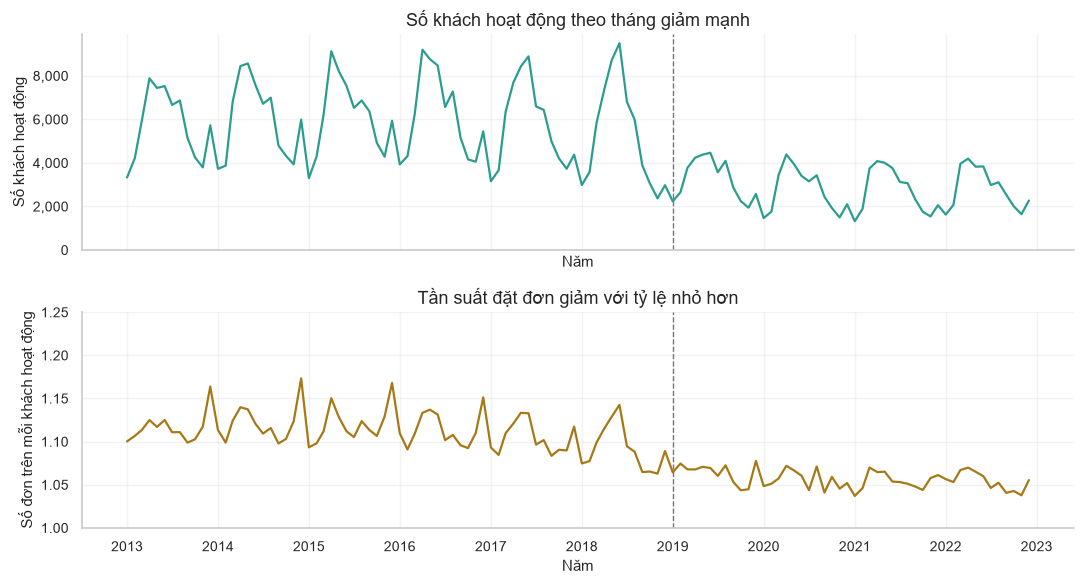

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(comparison_months["month"], comparison_months["active_customers"],
             color="#2A9D8F", linewidth=1.6)
axes[0].set_title("Số khách hoạt động theo tháng giảm mạnh")
axes[0].set_ylabel("Số khách hoạt động")
axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].plot(comparison_months["month"], comparison_months["orders_per_active_customer"],
             color="#A67816", linewidth=1.6)
axes[1].set_title("Tần suất đặt đơn giảm với tỷ lệ nhỏ hơn")
axes[1].set_ylabel("Số đơn trên mỗi khách hoạt động")
axes[1].set_ylim(1, 1.25)
for ax in axes:
    ax.axvline(POST_START, color="#777777", linestyle="--", linewidth=1)
    format_time_axis(ax)
plt.tight_layout()
plt.show()

**Kết quả:** Số khách hoạt động bình quân tháng giảm từ **5,824 xuống 2,891 (50.4%)**. Số đơn trên mỗi khách hoạt động giảm từ **1.116 xuống 1.059 (5.1%)**. Trục tần suất bắt đầu từ một, là mức tối thiểu của một khách hoạt động.

**Nhận xét:** Ít lượt khách-tháng hoạt động hơn chiếm phần lớn chênh lệch số đơn. Khi phân rã đẳng thức trên thang log, số khách hoạt động đóng góp **93.1%**, còn tần suất đóng góp **6.9%** vào thay đổi log của Orders. Đây là đóng góp về mặt số học, không phải tác động nhân quả hay tỷ lệ phương sai được giải thích. Do thành phần khách hàng thay đổi, không thể dùng so sánh tần suất này để kết luận cùng một nhóm người đã thay đổi hành vi ra sao.

**Câu hỏi tiếp theo:** Mức giảm số khách hoạt động phân bố thế nào giữa khách mới và khách quay lại?

## 7. Phân tích sâu hoạt động khách hàng

**Câu hỏi:** Hoạt động theo tháng giảm ở khách mới, khách quay lại, hay cả hai?

**Khách hàng mới** có đơn đầu tiên quan sát được trong tháng đó. **Khách quay lại có hoạt động** có đơn trong tháng và đã có đơn ở một tháng trước. Mỗi khách chỉ thuộc một nhóm trong từng tháng; nếu khách mới có đơn thứ hai ngay trong cùng tháng, họ vẫn được tính vào nhóm mới của tháng đó.

Các định nghĩa này dựa trên đơn được ghi nhận ở mọi trạng thái. “Mới” chỉ phản ánh lần đầu xuất hiện trong dữ liệu, chưa xác nhận kết quả thu hút khách từ marketing. “Quay lại” là số khách theo tháng, không phải tỷ lệ giữ chân.

In [13]:
first_order = orders_enriched.groupby("customer_id", as_index=False).agg(
    first_order_date=("order_date", "min"),
)
first_order["first_order_month"] = first_order["first_order_date"].dt.to_period("M").dt.to_timestamp()
customer_month = orders_enriched[["month", "customer_id"]].drop_duplicates().merge(
    first_order, on="customer_id", how="left", validate="many_to_one",
)
customer_month["customer_type"] = np.where(
    customer_month["month"].eq(customer_month["first_order_month"]),
    "New purchasing customers", "Returning active customers",
)
customer_groups = ["New purchasing customers", "Returning active customers"]
customer_type_pivot = customer_month.groupby(["month", "customer_type"]).size().unstack(fill_value=0)
customer_type_pivot = customer_type_pivot.reindex(
    index=monthly_metrics["month"], columns=customer_groups, fill_value=0,
)
np.testing.assert_array_equal(
    customer_type_pivot.sum(axis=1).to_numpy(), monthly_metrics["active_customers"].to_numpy(),
)
new_returning_summary = pd.DataFrame({
    "2013-2018": customer_type_pivot.loc["2013-01":"2018-12"].mean(),
    "2019-2022": customer_type_pivot.loc["2019-01":"2022-12"].mean(),
})
new_returning_summary["Monthly decrease"] = new_returning_summary["2013-2018"] - new_returning_summary["2019-2022"]
new_returning_summary["Percent change"] = new_returning_summary["2019-2022"] / new_returning_summary["2013-2018"] - 1
new_returning_summary["Share of active-customer decrease"] = (
    new_returning_summary["Monthly decrease"] / new_returning_summary["Monthly decrease"].sum()
)
show_table(new_returning_summary.reset_index(names="Monthly customer group"), {
    "2013-2018": "{:,.1f}", "2019-2022": "{:,.1f}",
    "Monthly decrease": "{:,.1f}", "Percent change": "{:+.1%}",
    "Share of active-customer decrease": "{:.1%}",
})

Monthly customer group,2013-2018,2019-2022,Monthly decrease,Percent change,Share of active-customer decrease
Khách mới,862.8,126.2,736.5,-85.4%,25.1%
Khách quay lại có hoạt động,"4,960.9","2,764.8","2,196.1",-44.3%,74.9%


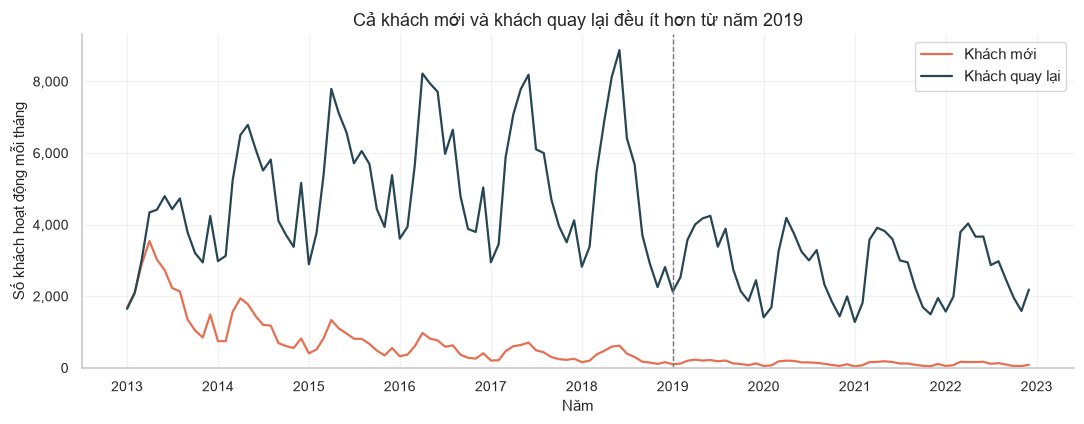

In [14]:
customer_plot = customer_type_pivot.loc["2013-01":"2022-12"]
fig, ax = plt.subplots(figsize=(11, 4.4))
for group, color in zip(customer_groups, ["#E76F51", "#264653"]):
    ax.plot(customer_plot.index, customer_plot[group], label={"New purchasing customers": "Khách mới",
                                                   "Returning active customers": "Khách quay lại"}[group],
            color=color, linewidth=1.6)
ax.axvline(POST_START, color="#777777", linestyle="--", linewidth=1)
ax.set_title("Cả khách mới và khách quay lại đều ít hơn từ năm 2019")
ax.set_ylabel("Số khách hoạt động mỗi tháng")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
format_time_axis(ax)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Kết quả:** Khách mới giảm từ **863 xuống 126 khách/tháng (85.4%)**, còn khách quay lại có hoạt động giảm từ **4,961 xuống 2,765 (44.3%)**. Nhóm quay lại chiếm khoảng **2,196 trong tổng mức giảm 2,933 lượt khách-tháng bình quân tháng (74.9%)**; nhóm mới chiếm **737 còn lại (25.1%)**.

**Nhận xét:** Nhóm mới giảm mạnh hơn về tỷ lệ, nhưng nhóm quay lại giảm nhiều hơn về số lượng tuyệt đối. Số khách mới đã giảm từ trước năm 2019, nên so sánh gộp không xác định được thời điểm hoạt động thu hút khách bắt đầu yếu đi. Số khách quay lại giảm cũng không đồng nghĩa với tỷ lệ giữ chân giảm, vì còn phụ thuộc quy mô và thành phần các nhóm khách trước đó. Phần tiếp theo dùng cùng khoảng theo dõi 365 ngày để xem xét hành vi đặt lại.

In [15]:
customers_with_first_order = first_order.merge(
    customers, on="customer_id", how="left", validate="one_to_one",
)
assert customers_with_first_order["signup_date"].notna().all()
signup_before_order_conflict = (
    customers_with_first_order["first_order_date"] < customers_with_first_order["signup_date"]
)
signup_conflict_count = int(signup_before_order_conflict.sum())
signup_conflict_share = signup_before_order_conflict.mean()

**Kiểm tra định nghĩa:** **80,623 trong 90,246 khách có đơn được ghi nhận (89.3%)** xuất hiện trong dữ liệu đơn hàng trước ngày đăng ký. Vì vậy, chưa thể dùng ngày đăng ký để đo quá trình kích hoạt khách hàng một cách đáng tin cậy. Phân tích dùng ngày đặt đơn đầu tiên quan sát được và không kết luận về tỷ lệ chuyển đổi từ đăng ký sang mua hàng.

**Câu hỏi:** Trong những khách có đơn đầu tiên được ghi nhận, các nhóm xuất hiện muộn hơn có ít đặt đơn thứ hai hơn trong cùng khoảng theo dõi không?

**Tỷ lệ đặt lại trong 365 ngày** được định nghĩa như sau:

- **Nhóm khách (cohort):** xác định theo năm của đơn đầu tiên quan sát được, giữ mọi trạng thái đơn.
- **Tử số:** số khách có mã đơn thứ hai khác mã đơn đầu, từ ngày 0 đến hết ngày 365 sau đơn đầu tiên. Hai đơn khác nhau trong cùng ngày vẫn được tính.
- **Mẫu số:** toàn bộ khách có đơn đầu tiên trong các nhóm được xét, kể cả người không có đơn thứ hai. Mỗi khách có trọng số bằng nhau; tỷ lệ gộp không phải trung bình các tỷ lệ theo năm.
- **Khoảng quan sát:** đến **ngày 31/12/2022**. Ngày đặt đơn đầu tiên cộng 365 ngày của mọi khách được đưa vào phải không vượt quá mốc này.
- **Nhóm đủ điều kiện:** các năm đầy đủ **2013-2021**. Loại năm 2012 chưa đầy đủ; **loại toàn bộ 1,322 khách xuất hiện lần đầu trong năm 2022** vì chưa ai có đủ 365 ngày theo dõi.

Cách này tránh thiếu thời gian theo dõi ở các tỷ lệ được báo cáo, nhưng vẫn có giới hạn. Không biết các lần mua trước tháng 7/2012, và không thể xác minh tính liên tục của lịch sử hay độ ổn định của mã khách ngoài các tệp hiện có. “Lần đầu quan sát được” chưa chắc là khách thực sự mới. Khách chưa có đơn nào không nằm trong mẫu số. Chỉ số đo việc có đơn thứ hai trong 365 ngày, không phải tỷ lệ còn hoạt động đúng ngày 365 hay tỷ lệ giữ chân dựa trên giao dịch đã hoàn tất.

In [16]:
ordered_customer_orders = orders_enriched.sort_values(["customer_id", "order_date", "order_id"]).copy()
ordered_customer_orders["order_sequence"] = ordered_customer_orders.groupby("customer_id").cumcount()
first_second = ordered_customer_orders[ordered_customer_orders["order_sequence"] < 2]
cohorts = first_second.pivot(
    index="customer_id", columns="order_sequence", values="order_date",
).reindex(columns=[0, 1]).rename(columns={0: "first_order", 1: "second_order"}).reset_index()
cohorts.columns.name = None
cohorts["first_order_year"] = cohorts["first_order"].dt.year
cohorts["window_end"] = cohorts["first_order"] + pd.Timedelta(days=365)
cohorts["complete_365_days"] = cohorts["window_end"] <= CUTOFF
cohorts["days_to_second"] = (cohorts["second_order"] - cohorts["first_order"]).dt.days
assert cohorts["days_to_second"].dropna().ge(0).all()
cohorts["repeat_within_365"] = cohorts["days_to_second"].between(0, 365)
eligible_cohorts = cohorts[cohorts["first_order_year"].between(2013, 2021)].copy()
assert eligible_cohorts["complete_365_days"].all()
assert len(eligible_cohorts) == eligible_cohorts["customer_id"].nunique()
assert not cohorts.loc[cohorts["first_order_year"].eq(2022), "complete_365_days"].any()

cohort_year = eligible_cohorts.groupby("first_order_year", as_index=False).agg(
    customers=("customer_id", "nunique"),
    repeat_within_365=("repeat_within_365", "sum"),
)
cohort_year["repeat_rate"] = cohort_year["repeat_within_365"] / cohort_year["customers"]
eligible_cohorts["period"] = np.where(
    eligible_cohorts["first_order_year"] <= 2018, "2013-2018", "2019-2021",
)
cohort_period_summary = eligible_cohorts.groupby("period", as_index=False).agg(
    customers=("customer_id", "nunique"),
    complete_windows=("complete_365_days", "sum"),
    repeat_within_365=("repeat_within_365", "sum"),
    latest_window_end=("window_end", "max"),
)
cohort_period_summary["repeat_rate"] = (
    cohort_period_summary["repeat_within_365"] / cohort_period_summary["customers"]
)
show_table(cohort_period_summary.rename(columns={
    "period": "First observed order years", "customers": "All cohort customers",
    "complete_windows": "Complete 365-day windows",
    "repeat_within_365": "Customers with repeat by day 365",
    "latest_window_end": "Latest window end", "repeat_rate": "365-day repeat rate",
}), {
    "All cohort customers": "{:,.0f}", "Complete 365-day windows": "{:,.0f}",
    "Customers with repeat by day 365": "{:,.0f}",
    "Latest window end": lambda x: x.strftime("%Y-%m-%d"),
    "365-day repeat rate": "{:.1%}",
})

First observed order years,All cohort customers,Complete 365-day windows,Customers with repeat by day 365,Latest window end,365-day repeat rate
2013-2018,"62,118","62,118","23,444",2019-12-31,37.7%
2019-2021,"4,738","4,738",461,2022-12-31,9.7%


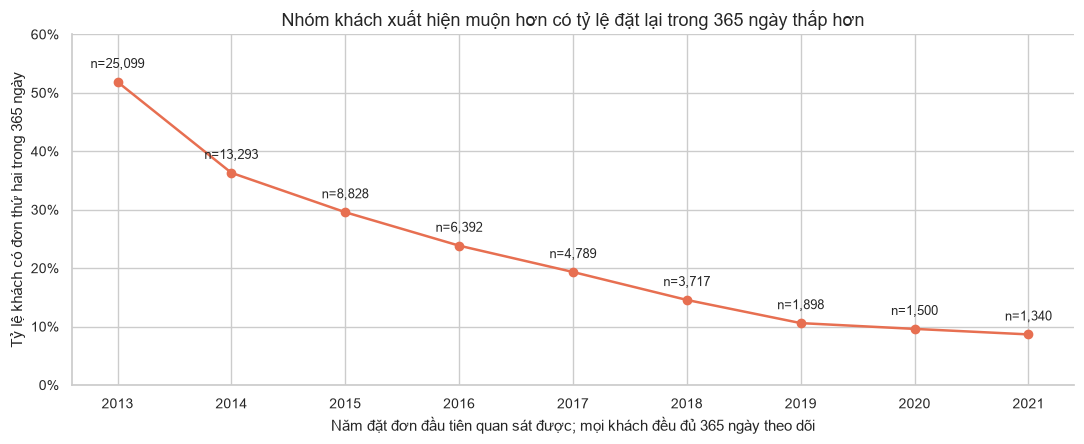

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(cohort_year["first_order_year"], cohort_year["repeat_rate"],
        marker="o", color="#E76F51", linewidth=1.8)
for row in cohort_year.itertuples():
    ax.annotate(f"n={row.customers:,}", (row.first_order_year, row.repeat_rate),
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9)
ax.set_title("Nhóm khách xuất hiện muộn hơn có tỷ lệ đặt lại trong 365 ngày thấp hơn")
ax.set_xlabel("Năm đặt đơn đầu tiên quan sát được; mọi khách đều đủ 365 ngày theo dõi")
ax.set_ylabel("Tỷ lệ khách có đơn thứ hai trong 365 ngày")
ax.set_xticks(cohort_year["first_order_year"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.60)
plt.tight_layout()
plt.show()

**Kết quả:** **23,444 trong 62,118 khách (37.7%)** thuộc các nhóm 2013-2018 có đơn thứ hai trong 365 ngày, so với **461 trong 4,738 khách (9.7%)** thuộc các nhóm 2019-2021. Chênh lệch là **28.0 điểm phần trăm**, với đầy đủ 365 ngày theo dõi cho mọi khách được đưa vào.

**Nhận xét:** Tỷ lệ đặt lại theo năm đã giảm trước năm 2019: **51.9% ở nhóm 2013, 14.6% ở nhóm 2018 và 8.7% ở nhóm 2021**. Vì vậy, so sánh gộp không xác nhận một bước giảm mới về giữ chân vào năm 2019. Tín hiệu đặt lại trong cùng khoảng theo dõi khác với số khách quay lại theo tháng, vốn phụ thuộc quy mô tập khách tích lũy. Kết quả gợi ý nên tìm hiểu trải nghiệm và thành phần khách hàng, nhưng không xác định hiệu quả của một biện pháp can thiệp hay mức doanh thu giảm do hành vi đặt lại.

**Giới hạn:** Thành phần khách, bối cảnh từng năm và lịch sử trước khi dữ liệu bắt đầu có thể khác nhau giữa các nhóm. Đơn thứ hai có thể bị hủy hoặc trả lại; hai nhóm gộp cũng bao phủ số năm khác nhau. Không so sánh tỷ lệ đặt lại và số đơn trong toàn bộ lịch sử vì nhóm xuất hiện sớm có thời gian theo dõi dài hơn. Tại mốc chốt dữ liệu, chưa biết đầy đủ kết quả 365 ngày của các nhóm năm 2022.

## 8. Hàm ý cho doanh nghiệp

**Câu hỏi:** Dữ liệu hỗ trợ quyết định nào, và cần kiểm tra điều gì trước?

| Bằng chứng | Ý nghĩa | Hướng xử lý phù hợp | Điều chưa rõ |
|---|---|---|---|
| Doanh thu giảm 41.5%; số đơn giảm 52.9%; AOV tăng 24.2%. | Số đơn là thành phần giảm; AOV bù lại một phần về mặt số học. | Ưu tiên theo dõi số đơn và khách hoạt động mỗi tháng. Đánh giá biện pháp tăng giá trị đơn cùng biên lợi nhuận và số đơn, thay vì mặc định chúng sẽ giải quyết mức giảm. | Chưa đánh giá tác động của thay đổi giá hay chương trình marketing. |
| Khách hoạt động giảm 50.4%; tần suất có trọng số giảm 5.1%. | Tập khách hoạt động theo tháng nhỏ hơn chiếm phần lớn chênh lệch số đơn. | Theo dõi riêng khách mới, khách quay lại và khách hoạt động trở lại, với mã khách và định nghĩa nhất quán. | Thành phần khách thay đổi theo tháng; đây không phải nhóm khách cố định hay số khách mất vĩnh viễn. |
| Khách mới giảm 85.4%; khách quay lại có hoạt động giảm 44.3%; tỷ lệ đặt lại của nhóm đủ thời gian theo dõi là 37.7% và 9.7%. | Cả khách mới lẫn hành vi đặt lại đều cần được xem xét; chưa xác định yếu tố nào là nguyên nhân gốc. | Kiểm tra dữ liệu sự kiện và độ đầy đủ của lịch sử, rồi đối chiếu thay đổi năm 2019 với hồ sơ marketing, sản phẩm và dịch vụ có ngày ghi nhận. Dùng thử nghiệm có đối chứng để đánh giá chương trình thu hút khách hoặc khuyến khích đặt lại. | Các chỉ số này chưa cho biết mức tiếp cận marketing, chi phí, thành phần khách hay kết quả giao dịch đã hoàn tất. |
| Doanh thu ngày của tháng 4-6 bằng khoảng 1.48-1.53 lần bình quân năm trong các năm đầy đủ. | So sánh trực tiếp giữa các tháng có thể nhầm mùa vụ với thay đổi hiệu quả hoạt động. | So sánh các thời điểm tương đồng về mùa vụ và kiểm tra thêm trước khi dùng mẫu hình quá khứ để lập kế hoạch. | Mùa vụ trong dữ liệu mô phỏng không bảo đảm nhu cầu tương lai hay đủ cơ sở để quyết định tăng tồn kho ở mức cụ thể. |

## 9. Kết luận và bước tiếp theo

**Kết quả được dữ liệu hỗ trợ rõ:** Doanh thu giai đoạn 2019-2022 thấp hơn chủ yếu gắn với số đơn được ghi nhận thấp hơn: doanh thu bình quân tháng giảm **41.5%**, số đơn giảm **52.9%**, còn AOV tăng **24.2%**. Khi phân rã số đơn, tập khách hoạt động theo tháng nhỏ hơn **50.4%** là thành phần chính, bên cạnh tần suất có trọng số giảm **5.1%**. Đây là kết quả mô tả và phân rã số học đã được đối chiếu, không phải ước lượng tác động nhân quả.

**Tín hiệu đáng chú ý nhưng còn giới hạn:** Khách mới giảm **85.4%**, còn khách quay lại có hoạt động giảm **44.3%** và chiếm phần lớn mức giảm tuyệt đối của số khách hoạt động. Ở phân tích riêng, các nhóm đủ thời gian theo dõi có tỷ lệ đặt lại trong 365 ngày là **37.7% và 9.7%**. Cả số khách mới lẫn tỷ lệ đặt lại theo năm đã yếu đi trước năm 2019. Những tín hiệu này đáng tìm hiểu thêm, nhưng chưa chứng minh hoạt động thu hút hoặc giữ chân khách kém đi đã gây giảm doanh thu: thời điểm thu hút khách chưa được xác minh, ngày đăng ký mâu thuẫn với ngày đặt đơn, thành phần khách có thể thay đổi và dữ liệu có cả đơn chưa hoàn tất.

**Ưu tiên cho doanh nghiệp:** Trước hết, kiểm tra mã khách, ngày ghi nhận sự kiện và độ đầy đủ của lịch sử. Sau đó, đối chiếu các thay đổi có hồ sơ quanh năm 2019 và theo dõi khách mới, khách quay lại, khách hoạt động trở lại; chỉ tính tỷ lệ cohort khi đủ thời gian theo dõi. Chỉ thử nghiệm chương trình thu hút hoặc khuyến khích đặt lại sau khi xác định nhóm khách mục tiêu và đo phần tăng thêm của đơn hoàn tất, doanh thu và biên lợi nhuận. Cần xét mùa vụ khi theo dõi; mẫu hình tháng 8 vẫn là câu hỏi thứ yếu.

## Từ EDA đến bài toán dự báo

**Câu hỏi:** Có thể dự báo doanh thu từng ngày tốt đến đâu nếu chỉ dùng thông tin đã có tại thời điểm lập dự báo?

**Mục tiêu và đơn vị quan sát:** Dự báo **Revenue theo từng ngày, đơn vị VND**, giữ định nghĩa gồm mọi trạng thái đơn của bộ dữ liệu. Dữ liệu theo ngày phù hợp với cả chuỗi lịch sử và lịch nộp kết quả. Tổng theo tuần/tháng có thể hỗ trợ đánh giá và lập kế hoạch. Nếu dùng mô hình theo tháng, cần kiểm tra riêng cách phân bổ xuống từng ngày, kể cả các tháng đầu hoặc cuối chưa đầy đủ.

**Mốc dự báo (forecast origin):** Dùng thông tin có sau khi chốt **ngày 31/12/2022**, để dự báo từ **ngày 1/1/2023 đến ngày 1/7/2024**. Thông tin phải thực sự có sẵn tại mốc này, không chỉ có ngày sự kiện phù hợp; cần tính đến độ trễ báo cáo. Tệp mẫu nộp kết quả chỉ cung cấp ngày, không cung cấp giá trị mục tiêu đã quan sát.

**Liên hệ với EDA:** Tháng 4-6 mạnh và tháng 10-12 yếu gợi ý dùng đặc trưng mùa vụ năm. Mức doanh thu thấp hơn sau 2019 là lý do để so sánh dữ liệu gần đây với lịch sử mở rộng. Doanh thu giảm **41.5%**, số đơn giảm **52.9%**, dù AOV tăng **24.2%**; khách hoạt động giảm **50.4%**. Các kết quả này gợi ý dùng đặc trưng trễ về số đơn và khách hàng, nhưng không chứng minh quan hệ nhân quả và cũng không cho biết trước số đơn hay khách hàng tương lai.

In [18]:
forecast_origin = CUTOFF
forecast_dates = pd.read_csv(
    DATA_DIR / "sample_submission.csv", usecols=["Date"], parse_dates=["Date"],
)["Date"].sort_values()
revenue_history = sales.set_index("Date")["Revenue"].sort_index().asfreq("D")
assert not revenue_history.isna().any()
assert revenue_history.index.max() == forecast_origin
assert forecast_dates.is_unique
assert forecast_dates.tolist() == list(pd.date_range(
    forecast_origin + pd.Timedelta(days=1), pd.Timestamp("2024-07-01"), freq="D",
))
forecast_horizon = len(forecast_dates)
assert forecast_horizon == 548
assert pd.Timestamp("2024-02-29") in set(forecast_dates)

forecast_calendar = pd.DataFrame([
    ["Observed Revenue", revenue_history.index.min(), forecast_origin, len(revenue_history)],
    ["Forecast dates; Revenue unknown", forecast_dates.min(), forecast_dates.max(), forecast_horizon],
], columns=["Role", "First day", "Last day", "Days"])
show_table(forecast_calendar, {
    "First day": lambda x: x.strftime("%Y-%m-%d"),
    "Last day": lambda x: x.strftime("%Y-%m-%d"), "Days": "{:,.0f}",
})

Role,First day,Last day,Days
Doanh thu đã quan sát,2012-07-04,2022-12-31,"3,833"
Ngày cần dự báo; chưa biết doanh thu,2023-01-01,2024-07-01,548


**Kiểm tra dữ liệu:** Có **3,833 ngày quan sát liên tục** để xây dựng dự báo cho **548 ngày**, khoảng 18 tháng, gồm cả ngày nhuận năm 2024. Giai đoạn tiếp theo có thể **làm sạch, lựa chọn, tổng hợp và tạo bảng đặc trưng từ các bảng dữ liệu gốc liên quan**, không bị giới hạn ở các cột ban đầu của `sales.csv`. Cần tổng hợp từng nguồn về đúng đơn vị quan sát trước khi nối bảng, kiểm tra quan hệ nối và đối chiếu doanh thu.

| Nhóm đặc trưng đề xuất | Thông tin được phép dùng tại mỗi mốc dự báo |
|---|---|
| Lịch sử doanh thu | Giá trị trễ (lag) 1, 7, 28 và 365 ngày; trung bình, mức biến động và xu hướng trên cửa sổ 7/28/90 ngày trước đó, kết thúc không muộn hơn mốc dự báo. |
| Lịch / mùa vụ | Thứ, tháng của ngày cần dự báo, thành phần Fourier theo năm và ngày lễ đã biết trước. Quy định rõ cách xử lý ngày nhuận. |
| Orders, AOV và khách hàng | Số lượng trễ, tỷ số Revenue/Orders và số khách hoạt động/mới/quay lại riêng biệt trong cửa sổ lịch sử. Phải đếm lại khách riêng biệt trong từng cửa sổ, không cộng số khách riêng biệt của từng ngày. |
| Lưu lượng truy cập | Số phiên, lượt xem trang trễ và cơ cấu nguồn truy cập, tổng hợp theo ngày. Lịch sử bắt đầu từ 2013; thiếu dữ liệu trước đó không có nghĩa là lưu lượng bằng không. |
| Khuyến mãi | Tỷ lệ đơn có khuyến mãi hoặc tín hiệu chiết khấu trong lịch sử từ các dòng hàng có ngày ghi nhận. Chỉ dùng lịch khuyến mãi tương lai khi có bằng chứng lịch đó đã được duyệt và biết tại mốc dự báo. |
| Vận hành, nếu hữu ích | Thông tin tồn kho/hết hàng trễ từ các kỳ đã chốt và đã có báo cáo; tín hiệu trả hàng/giao hàng chỉ được dùng sau ngày sự kiện và ngày báo cáo. Kiểm tra mức cải thiện trước khi đưa vào. |

**Tránh rò rỉ dữ liệu (leakage):** Không có sẵn Revenue, Orders, AOV, khách hàng, lưu lượng, mức sử dụng khuyến mãi hay kết quả vận hành thực tế trong tương lai. Phải bỏ chúng, dự báo riêng trong từng lượt kiểm định, hoặc ghi rõ các giả định bên ngoài là kịch bản. Ngày bắt đầu khuyến mãi không chứng minh lịch đã được biết trước. Loại các tổng hợp ngay ngày cần dự báo, cửa sổ lấy cả dữ liệu trước và sau, dữ liệu kỳ sau được điền ngược về trước, kết quả cohort tương lai và việc chuẩn hóa/điền thiếu/tách mùa vụ trên toàn bộ chuỗi. Chỉ khớp các bước tiền xử lý trên lịch sử huấn luyện.

**Dự báo một bước và 548 bước:** Khi dự báo ngày kế tiếp, lag-1 hoặc thống kê cửa sổ đã dịch thời gian là thông tin đã biết. Với bước dự báo (h>1), các giá trị trễ tính theo ngày đích có thể nằm sau mốc dự báo cố định; ngay cả lag-365 cũng chưa biết khi (h>365). Không tạo đặc trưng kiểm định bằng cách dịch toàn bộ chuỗi thực tế. Cần so sánh dự báo đệ quy, dùng lại giá trị dự báo và có sai số tích lũy, với dự báo trực tiếp hoặc đồng thời nhiều bước, chỉ dùng thống kê tại mốc dự báo, độ dài dự báo và lịch của ngày đích. Nhãn của dữ liệu huấn luyện cũng phải nằm trước hoặc đúng thời điểm chốt dữ liệu (cutoff). Cập nhật bằng số thực tế của các ngày mới là bài toán dự báo một bước cuốn chiếu khác, không thay thế được đánh giá dài hạn này.

**Câu hỏi kiểm định theo thời gian (backtesting):** Phương pháp có dự báo tốt qua giai đoạn đổi mức doanh thu và ở các bước xa không?

Dùng các lượt kiểm định với mốc dự báo tiến dần bên dưới, dự báo **đủ 548 ngày mà không cập nhật số thực tế trong từng lượt**. So sánh lịch sử mở rộng với một số cửa sổ gần nhất đã chọn trước, chẳng hạn hai hoặc ba năm. Chỉ dùng các lượt phát triển để chọn đặc trưng, độ dài lịch sử và siêu tham số, rồi chốt cấu hình trước lượt kiểm định cuối. Các khoảng kiểm định trước có chồng lấn, nên báo cáo riêng từng lượt, không coi sai số là các quan sát độc lập.

Lượt kiểm định cuối kết thúc ở ngày quan sát cuối cùng và được giữ riêng để đánh giá cấu hình đã chọn, dù EDA đã xem giai đoạn này. Sau đánh giá, huấn luyện lại quy trình được chọn với dữ liệu đến ngày 31/12/2022. Không chia ngẫu nhiên tập huấn luyện và kiểm tra.

In [19]:
backtest_specs = [
    ("Development 1", "2017-12-31"),
    ("Development 2", "2018-12-31"),
    ("Development 3", "2019-12-31"),
    ("Final backtest", "2021-07-01"),
]
backtest_rows = []
for role, origin_text in backtest_specs:
    origin = pd.Timestamp(origin_text)
    train_dates = revenue_history.index[revenue_history.index <= origin]
    validation_dates = pd.date_range(
        origin + pd.Timedelta(days=1), periods=forecast_horizon, freq="D",
    )
    assert train_dates.max() < validation_dates.min()
    assert validation_dates.max() <= forecast_origin
    assert validation_dates.isin(revenue_history.index).all()
    backtest_rows.append({
        "Role": role, "Origin": origin, "Training days": len(train_dates),
        "Forecast start": validation_dates.min(), "Forecast end": validation_dates.max(),
        "Horizon": len(validation_dates),
    })
backtest_plan = pd.DataFrame(backtest_rows)
assert backtest_plan.iloc[:-1]["Forecast end"].le(backtest_plan.iloc[-1]["Origin"]).all()
assert backtest_plan.iloc[-1]["Forecast end"] == forecast_origin
show_table(backtest_plan, {
    "Origin": lambda x: x.strftime("%Y-%m-%d"),
    "Forecast start": lambda x: x.strftime("%Y-%m-%d"),
    "Forecast end": lambda x: x.strftime("%Y-%m-%d"),
    "Training days": "{:,.0f}", "Horizon": "{:,.0f}",
})

Role,Origin,Training days,Forecast start,Forecast end,Horizon
Lượt phát triển 1,2017-12-31,"2,007",2018-01-01,2019-07-02,548
Lượt phát triển 2,2018-12-31,"2,372",2019-01-01,2020-07-01,548
Lượt phát triển 3,2019-12-31,"2,737",2020-01-01,2021-07-01,548
Kiểm định cuối,2021-07-01,"3,285",2021-07-02,2022-12-31,548


**Thứ tự thử mô hình ở giai đoạn tiếp theo:**

| Bước | Mô hình đề xuất và tiêu chí lựa chọn |
|---|---|
| Mô hình mốc (baseline) | Naive dùng giá trị cuối cùng và seasonal naive theo tuần/năm, lặp lại mùa đã quan sát cho toàn bộ khoảng dự báo, với quy tắc xử lý ngày nhuận rõ ràng. |
| Mô hình thống kê | ETS và họ ARIMA; cân nhắc đặc trưng lịch/Fourier cho mùa vụ năm của dữ liệu ngày, thay vì buộc mô hình dùng cấu trúc mùa vụ quá lớn. |
| Học máy | Hồi quy tuyến tính có điều chuẩn (regularized linear regression), sau đó là mô hình boosting dựa trên cây, với cùng thông tin hợp lệ tại mốc dự báo và cùng cách đánh giá đủ khoảng dự báo. Đặc trưng bổ sung phải cải thiện so với mô hình chỉ dùng doanh thu và lịch. |
| Học sâu (deep learning) | Chỉ xét khi kết quả kiểm định và cấu trúc dữ liệu cho thấy phù hợp. Một chuỗi với khoảng mười chu kỳ năm chưa đủ để ưu tiên học sâu. |

**Đánh giá:** Báo cáo **MAE và RMSE theo ngày, đơn vị VND**, cùng **R²** là chỉ số bổ sung và có thể âm. Xem độ chệch có dấu, sai số doanh thu theo tháng/lũy kế, mùa cao điểm/thấp điểm và các nhóm bước dự báo **1-30, 31-90, 91-365 và 366-548 ngày**. So sánh kết quả quanh thời điểm đổi mức và trong giai đoạn sau đó; đánh giá cả khoảng bất định bên cạnh dự báo điểm. Kết quả một bước tốt không bảo đảm dự báo 548 ngày tốt.

**Ứng dụng và hướng tiếp tục:** Chọn bài toán **dự báo Revenue theo ngày từ mốc cố định cuối năm 2022**, dùng thông tin lịch cùng tín hiệu doanh thu và hoạt động đã có trong quá khứ. Kết quả hỗ trợ phân bổ nguồn lực theo mùa và xây dựng kịch bản doanh thu; mức bất định cần phản ánh khoảng dự báo dài và khả năng mặt bằng doanh thu thay đổi. Không thể mặc định mức thấp sau 2019 sẽ kéo dài hay doanh thu chắc chắn phục hồi. **Notebook này chưa huấn luyện mô hình dự báo.**